In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%matplotlib inline

In [4]:
df = pd.read_csv('../data/raw/Telco_Customer_Churn.csv')

In [5]:
print("Shape: ", df.shape)
print("\nSpalten: ", df.columns.tolist())
print("\nDatentypen: \n", df.dtypes)
print("\nFehlende Werte: \n", df.isnull().sum())
print("\nStatistische Zusammenfassung: \n", df.describe())
print("\nErsten 5 Zeilen: \n", df.head(5))
print("\nVerteilung der Zielvariable 'Churn': \n", df['Churn'].value_counts())
print("\nProzentuale Verteilung der Zielvariable 'Churn': \n", df['Churn'].value_counts(normalize=True).round(2) * 100)
print("\nLetzten 5 Zeilen: \n", df.tail(5))

Shape:  (7043, 21)

Spalten:  ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Datentypen: 
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Fehlende Werte: 
 customerID

In [6]:
# TotalChargers ist nicht numerisch
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
print(df["TotalCharges"].isnull().sum())

11


In [8]:
print(df[df['TotalCharges'].isnull()])

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  ... 

In [9]:
#Tenure is 0, therefore we can change Totalcharges to 0 as well
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [10]:
print(df["TotalCharges"].isnull().sum())

0


In [12]:
#Festlegen des Plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl", 8)

In [15]:
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

## Wie ist die Churn Rate verteilt?

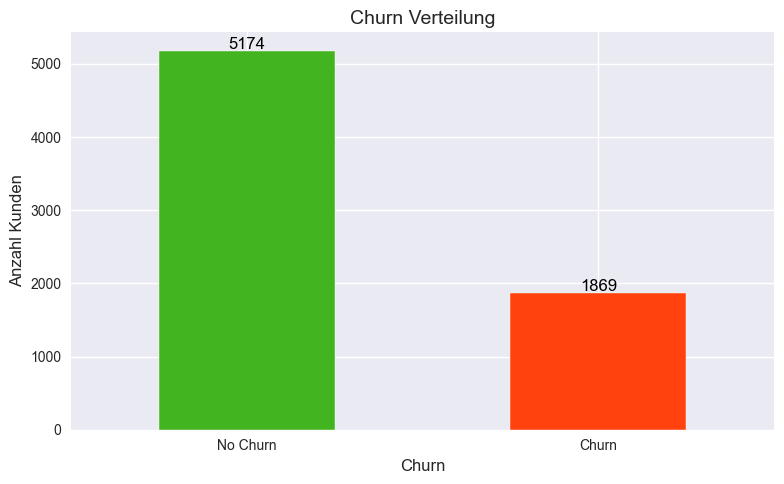

In [14]:
fig, ax = plt.subplots()

df['Churn'].value_counts().plot(kind='bar', ax=ax, edgecolor='white', color=["#42b41f", "#ff420e"])

ax.set_title('Churn Verteilung', fontsize=14)
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('Anzahl Kunden', fontsize=12)
ax.set_xticklabels(['No Churn', 'Churn'], rotation=0)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')
    
plt.tight_layout()
plt.savefig('../reports/figures/churn_distribution.png', dpi=300)
plt.show()


## Welche Vertragsart hat die höchste Churn-Rate?

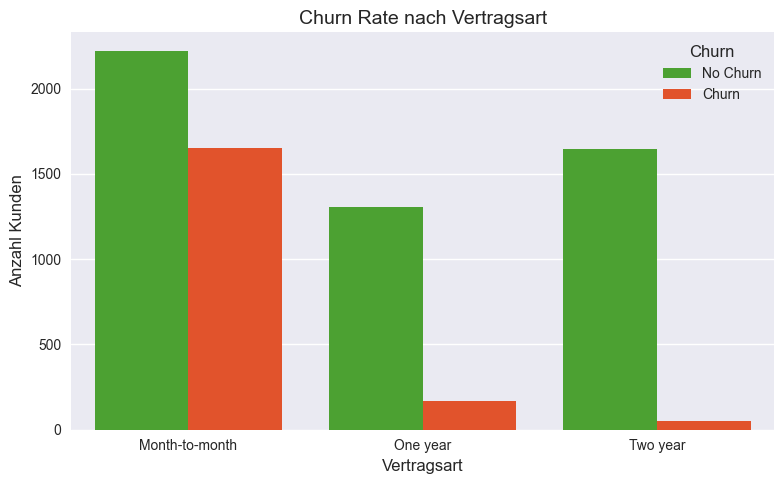

In [16]:
fig, ax = plt.subplots()
sns.countplot(x='Contract', hue='Churn', palette=['#42b41f', '#ff420e'], data=df, ax=ax)
ax.set_title('Churn Rate nach Vertragsart', fontsize=14)
ax.set_xlabel('Vertragsart', fontsize=12)
ax.set_ylabel('Anzahl Kunden', fontsize=12)
ax.legend(title='Churn', labels=['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('../reports/figures/churn_by_contract.png', dpi=300)
plt.show()

# Finding 1 -> Vertragsart ist ein größer Churn-Faktor

Kunden mit Monatsverträgen churnen deutlich häufiger als Langzeitkunden.
Bei Month-to-month Verträgen liegt die Churn-Rate bei ~43%, während
One-year (~11%) und Two-year Kunden (~3%) kaum kündigen.

**Empfehlung** Monatskunden aktiv zu Jahreverträgen bringen zum Beispiel durch Rabatte oder Vorteile für Längere Vertragsbindungen

## Business Frage 2: Wandern Kunden mit hohen Monatlichen Kosten eher als Kunden mit niedrigen monatlichen Kosten?

C:\Users\Bock\AppData\Local\Temp\ipykernel_11276\4201217154.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#42b41f', '#ff420e'], ax=ax)
C:\Users\Bock\AppData\Local\Temp\ipykernel_11276\4201217154.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Churn', 'Churn'])


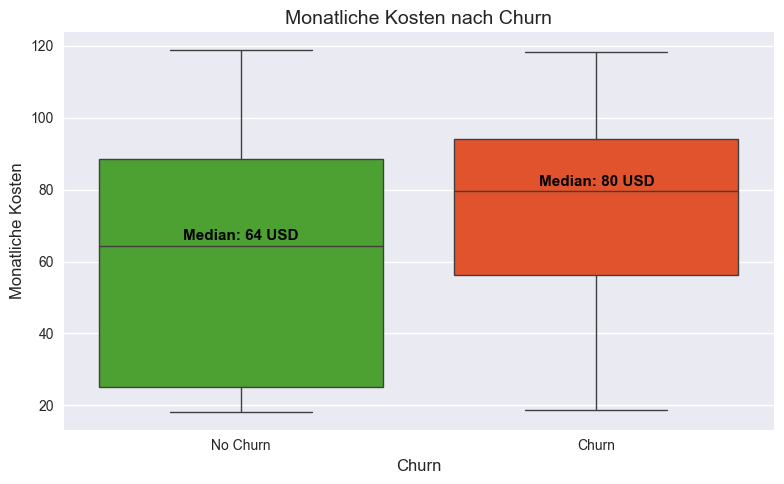

In [19]:
fig, ax = plt.subplots()
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#42b41f', '#ff420e'], ax=ax)
ax.set_title('Monatliche Kosten nach Churn', fontsize=14)
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('Monatliche Kosten', fontsize=12)
ax.set_xticklabels(['No Churn', 'Churn'])

medians = df.groupby('Churn')['MonthlyCharges'].median()

for i, churn_val in enumerate(['No', 'Yes']):
    ax.text(
        i,                              
        medians[churn_val] + 1.5,       
        f'Median: {medians[churn_val]:.0f} USD', 
        ha='center',
        fontsize=11,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.savefig('../reports/figures/monthly_charges_by_churn.png', dpi=300)
plt.show()

# Finding 2: Höhere Monatskosten erhöhen Churn-Risiko

Kunden die kündigen zahlen im Median 80 USD/Monat,
verglichen mit 64 USD bei treuen Kunden.

Churner sind eher eine homogene Gruppe im höheren Preissegment,
günstige Kunden bleiben deutlich loyaler.

**Business Empfehlung:** Kunden über 70 USD/Monat gezielt
mit Loyalty-Programmen oder Rabatten binden.

## Business Frage 3: Wie hängt die Vertragslaufzeit mit der Churn-Rate zusammen

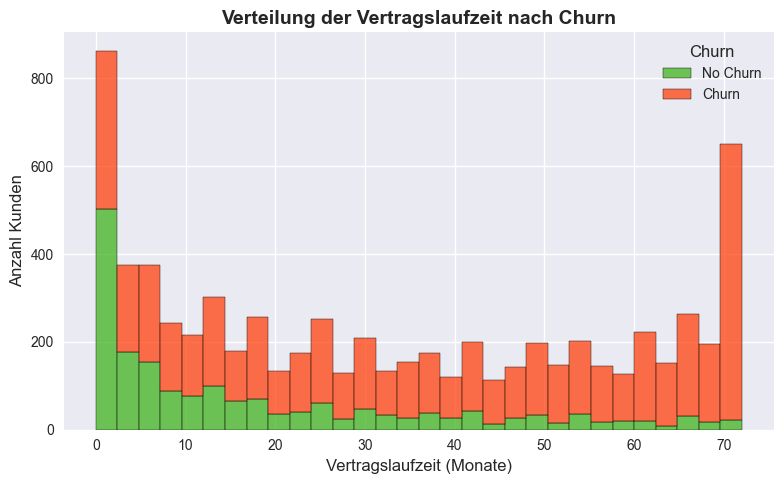

In [23]:
fig, ax = plt.subplots()
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette=['#ff420e', '#42b41f'], ax=ax, bins=30)
ax.set_title('Verteilung der Vertragslaufzeit nach Churn', fontsize=14 ,fontweight='bold')
ax.set_xlabel('Vertragslaufzeit (Monate)', fontsize=12)
ax.set_ylabel('Anzahl Kunden', fontsize=12)
ax.legend(title='Churn', labels=['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('../reports/figures/tenure_distribution_by_churn.png', dpi=300)
plt.show()

In [26]:
tenure_end = df[df['tenure'] >= 70].groupby('Churn').size()
print(tenure_end)

tenure_end_pct = df[df['tenure'] >= 70]['Churn'].value_counts(normalize=True) * 100
print("\nIn Prozent:")
print(tenure_end_pct)

Churn
No     628
Yes     23
dtype: int64

In Prozent:
Churn
No     96.466974
Yes     3.533026
Name: proportion, dtype: float64
